# Experiment 2 — CQT Cleaning (set_v1 / run_7)
Runs **demucs → CQT cleaning → predict** over both val splits.
Uses `hyperparam_set_v1 / run_7` (best run in set_v1) with DSP cleaning applied.

In [20]:
import sys, os
from pathlib import Path

REPO_ROOT = Path(os.getcwd())
SRC_DIR   = REPO_ROOT / 'src'
for p in [str(REPO_ROOT), str(SRC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

In [21]:
import torch
import numpy as np
import jams
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config
from src.run_pipeline import PipelineState, Node, run_pipeline
from src.nodes import stem_extraction, guitar_stem_cleaning, load_model, predict
from evaluation.metrics import calculate_note_level_metrics, calculate_onset_event_metrics

In [22]:
# ── Configuration ──────────────────────────────────────────────────────────────
CLEAN_VAL_DIR = REPO_ROOT / 'guitarset_demucs' / 'guitarset_mixed_dataset_clean' / 'val'
AUG_VAL_DIR   = REPO_ROOT / 'guitarset_demucs' / 'guitarset_mixed_dataset_augmented' / 'val'
ARTIFACTS_DIR = REPO_ROOT / 'hyperparam_set_v1'
ONSET_THRESH  = config.DEFAULT_TDR_THRESHOLD   # 0.5

# Auto-detect device
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

# Open-string MIDI pitches: string 0 = low E (40), ..., string 5 = high e (64)
OPEN_STRING_PITCHES = config.OPEN_STRING_PITCHES_MIDI  # {0:40,1:45,2:50,3:55,4:59,5:64}

Device: mps


In [23]:
# ── Select model run ───────────────────────────────────────────────────────────
runs = sorted([d for d in ARTIFACTS_DIR.iterdir()
               if d.is_dir() and (d / 'best_model.pth').exists()])

print('Available runs:')
for i, r in enumerate(runs):
    print(f'  [{i}] {r.name}')

Available runs:
  [0] run_4_Baseline_run72_re-run_with_new_aug_augEnabled
  [1] run_5_Test_Higher_Dropout_0.55_augEnabled
  [2] run_6_Test_More_Patient_Scheduler_12_augEnabled
  [3] run_7_Test_Higher_OnsetLossWeight_10_augEnabled
  [4] run_8_Test_Higher_Dropout_and_Patient_Scheduler_augEnabled


In [24]:
RUN_IDX = 3   # run_7_Test_Higher_OnsetLossWeight_10 — best val_tdr_f1 in v1

run_dir = runs[RUN_IDX]
print(f'Loading: {run_dir.name}')

_init_state = PipelineState(
    input_path=Path('/dev/null'),
    artifacts_dir=ARTIFACTS_DIR,
    extras={'device': DEVICE, 'run_name': run_dir.name},
)
_init_state = load_model(_init_state)
shared_model = _init_state.model
print('Model loaded.')

Loading: run_7_Test_Higher_OnsetLossWeight_10_augEnabled
--- Loading model from: best_model.pth ---
Reconstructed model init params: {'num_frames_rnn_input_dim': 1280, 'rnn_type': 'GRU', 'rnn_hidden_size': 768, 'rnn_layers': 2, 'rnn_dropout': 0.5, 'rnn_bidirectional': True}
Loading weights to device: mps
Model loaded successfully on device: mps
Model loaded.


In [25]:
def parse_gt_notes_from_jams(jams_path):
    """Return list of GT note dicts from a GuitarSet JAMS file.
    Each annotation in note_midi corresponds to one string (index 0-5).
    obs.time and obs.duration are plain floats (seconds).
    """
    j = jams.load(str(jams_path))
    note_anns = j.search(namespace='note_midi')
    notes = []
    for string_idx, ann in enumerate(note_anns):
        open_pitch = OPEN_STRING_PITCHES[string_idx]
        for obs in ann.data:
            pitch = int(round(obs.value))
            fret  = pitch - open_pitch
            if 0 <= fret <= config.MAX_FRETS:
                notes.append({
                    'start_time': float(obs.time),
                    'end_time':   float(obs.time + obs.duration),
                    'pitch_midi': pitch,
                    'string':     string_idx,
                    'fret':       fret,
                })
    return notes

In [26]:
def gt_notes_to_raw_tensor(gt_notes):
    """Convert GT note list to the (N,4) tensor format expected by metrics.py."""
    if not gt_notes:
        return torch.zeros((0, 4))
    rows = [[n['start_time'], n['end_time'], n['string'], n['fret']] for n in gt_notes]
    return torch.tensor(rows, dtype=torch.float32)

In [27]:
def evaluate_dataset(val_dir):
    wav_files = sorted(val_dir.glob('*.wav'))
    print(f'Evaluating {len(wav_files)} tracks from {val_dir.name}...')
    results = []
    for wav_path in tqdm(wav_files):
        track_id  = wav_path.stem
        jams_path = wav_path.with_suffix('.jams')
        if not jams_path.exists():
            print(f'  [SKIP] No JAMS for {track_id}')
            continue
        try:
            state = PipelineState(
                input_path=wav_path,
                artifacts_dir=ARTIFACTS_DIR,
                model=shared_model,
                extras={'device': DEVICE, 'run_name': run_dir.name},
            )
            state = run_pipeline(state, PIPELINE_NODES)
            pred_notes = state.predicted_notes or []
            gt_notes   = parse_gt_notes_from_jams(jams_path)
            gt_raw     = gt_notes_to_raw_tensor(gt_notes)
            tdr   = calculate_note_level_metrics(pred_notes, gt_raw)
            onset = calculate_onset_event_metrics(pred_notes, gt_raw)
            results.append({
                'track':           track_id,
                'n_gt_notes':      len(gt_notes),
                'n_pred_notes':    len(pred_notes),
                'tdr_precision':   tdr['tdr_precision'],
                'tdr_recall':      tdr['tdr_recall'],
                'tdr_f1':          tdr['tdr_f1'],
                'onset_precision': onset['onset_precision_event'],
                'onset_recall':    onset['onset_recall_event'],
                'onset_f1':        onset['onset_f1_event'],
            })
        except Exception as e:
            print(f'  [ERROR] {track_id}: {e}')
    return pd.DataFrame(results)

In [28]:
# ── Pipeline definition ────────────────────────────────────────────────────────
# HPSS disabled: diagnostic showed it removes 5–7 dB in presence/air bands
CLEANING_CONFIG = {"hpss": {"enabled": False}}

PIPELINE_NODES = [
    Node("stem_extraction",      stem_extraction),
    Node("guitar_stem_cleaning", lambda s: guitar_stem_cleaning(s, cleaning_config=CLEANING_CONFIG)),
    Node("predict",              predict),
]

## Clean Dataset

In [29]:
df_clean = evaluate_dataset(CLEAN_VAL_DIR)
print(f'\nDone. {len(df_clean)} tracks evaluated.')

Evaluating 72 tracks from val...


  0%|          | 0/72 [00:00<?, ?it/s]

INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/00_BN1-147-Gb_solo.wav


[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/00_Funk1-114-Ab_comp.wav


...

[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/05_SS1-68-E_comp.wav


[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/05_SS2-107-Ab_comp.wav


[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict

Done. 72 tracks evaluated.


In [30]:
# ── Summary statistics — Clean ─────────────────────────────────────────────────
metric_cols = ['tdr_precision','tdr_recall','tdr_f1','onset_precision','onset_recall','onset_f1']
summary = df_clean[metric_cols].agg(['mean','median','std']).T
summary.columns = ['mean','median','std']
print(f'Run: {run_dir.name}  |  Dataset: clean\n')
print(summary.to_string(float_format='{:.3f}'.format))

Run: run_7_Test_Higher_OnsetLossWeight_10_augEnabled  |  Dataset: clean

                 mean  median   std
tdr_precision   0.749   0.775 0.162
tdr_recall      0.698   0.781 0.224
tdr_f1          0.710   0.779 0.199
onset_precision 0.864   0.904 0.127
onset_recall    0.629   0.653 0.244
onset_f1        0.703   0.733 0.204


In [31]:
# ── Per-track table — Clean ────────────────────────────────────────────────────
df_clean.set_index('track')[metric_cols].sort_values('tdr_f1', ascending=False).style.format('{:.3f}').background_gradient(cmap='RdYlGn', axis=0)

,tdr_precision,tdr_recall,tdr_f1,onset_precision,onset_recall,onset_f1
track,,,,,,
03_BN1-129-Eb_solo,0.932,0.948,0.940,0.983,0.983,0.983
01_Rock1-90-C#_comp,0.887,0.955,0.920,0.971,0.573,0.721
05_Jazz1-200-B_solo,0.957,0.880,0.917,0.957,0.880,0.917
03_Funk1-114-Ab_solo,0.944,0.885,0.914,0.966,0.896,0.930
02_BN2-131-B_solo,0.909,0.909,0.909,0.955,0.955,0.955
05_BN1-129-Eb_solo,0.929,0.886,0.907,0.952,0.909,0.930
04_Rock1-90-C#_solo,0.915,0.878,0.897,0.957,0.905,0.931
01_Funk3-98-A_solo,0.914,0.867,0.889,0.957,0.903,0.929
03_BN2-131-B_solo,0.924,0.847,0.884,0.955,0.875,0.913


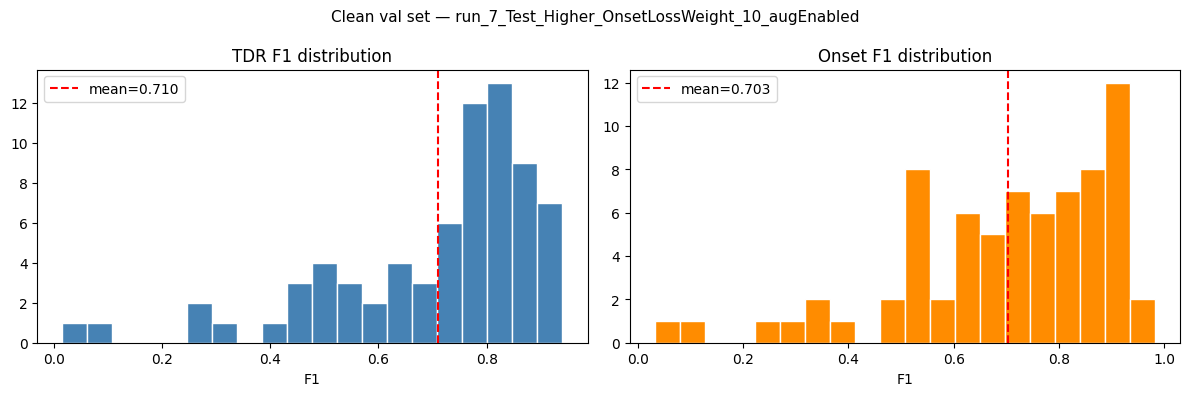

In [32]:
# ── Distribution plots — Clean ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Clean val set — {run_dir.name}', fontsize=11)

axes[0].hist(df_clean['tdr_f1'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df_clean['tdr_f1'].mean(), color='red', linestyle='--', label=f'mean={df_clean["tdr_f1"].mean():.3f}')
axes[0].set_title('TDR F1 distribution')
axes[0].set_xlabel('F1'); axes[0].legend()

axes[1].hist(df_clean['onset_f1'], bins=20, color='darkorange', edgecolor='white')
axes[1].axvline(df_clean['onset_f1'].mean(), color='red', linestyle='--', label=f'mean={df_clean["onset_f1"].mean():.3f}')
axes[1].set_title('Onset F1 distribution')
axes[1].set_xlabel('F1'); axes[1].legend()

plt.tight_layout()
plt.show()

In [33]:
# ── Best and worst tracks — Clean ──────────────────────────────────────────────
n = 5
print(f'Top {n} tracks (TDR F1):')
print(df_clean.nlargest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))
print(f'\nBottom {n} tracks (TDR F1):')
print(df_clean.nsmallest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))

Top 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
  03_BN1-129-Eb_solo 0.940171  0.982759          58
 01_Rock1-90-C#_comp 0.919732  0.720524         288
 05_Jazz1-200-B_solo 0.916667  0.916667          50
03_Funk1-114-Ab_solo 0.913978  0.929730          96
   02_BN2-131-B_solo 0.909091  0.954545          66

Bottom 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
  02_SS2-107-Ab_comp 0.015625  0.031873         235
    02_SS2-88-F_comp 0.088235  0.106870         241
02_Funk3-112-C#_comp 0.269841  0.250000         200
  00_BN1-147-Gb_solo 0.272000  0.380165          89
  02_Funk3-98-A_comp 0.294416  0.302703         130


## Augmented Dataset

In [34]:
df_aug = evaluate_dataset(AUG_VAL_DIR)
print(f'\nDone. {len(df_aug)} tracks evaluated.')

Evaluating 72 tracks from val...


  0%|          | 0/72 [00:00<?, ?it/s]

INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/00_BN1-129-Eb_comp.wav


[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/00_BN1-129-Eb_solo.wav


...

[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/05_SS3-84-Bb_solo.wav


[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict


INFO:stem_extraction:Using device: mps
INFO:stem_extraction:Using cached stem: /Users/jonathanc/dev/Tablio/output/extracted_guitar_stems/05_SS3-98-C_comp.wav


[RUN]  stem_extraction
[RUN]  guitar_stem_cleaning
[RUN]  predict

Done. 72 tracks evaluated.


In [35]:
# ── Summary statistics — Augmented ────────────────────────────────────────────
summary = df_aug[metric_cols].agg(['mean','median','std']).T
summary.columns = ['mean','median','std']
print(f'Run: {run_dir.name}  |  Dataset: augmented\n')
print(summary.to_string(float_format='{:.3f}'.format))

Run: run_7_Test_Higher_OnsetLossWeight_10_augEnabled  |  Dataset: augmented

                 mean  median   std
tdr_precision   0.680   0.709 0.176
tdr_recall      0.681   0.720 0.203
tdr_f1          0.672   0.719 0.184
onset_precision 0.798   0.862 0.152
onset_recall    0.663   0.707 0.224
onset_f1        0.702   0.729 0.174


In [36]:
# ── Per-track table — Augmented ───────────────────────────────────────────────
df_aug.set_index('track')[metric_cols].sort_values('tdr_f1', ascending=False).style.format('{:.3f}').background_gradient(cmap='RdYlGn', axis=0)

,tdr_precision,tdr_recall,tdr_f1,onset_precision,onset_recall,onset_f1
track,,,,,,
05_Rock1-130-A_solo,0.983,0.967,0.975,0.983,0.967,0.975
02_SS3-98-C_solo,0.923,0.945,0.934,0.946,0.969,0.957
05_SS3-84-Bb_solo,0.884,0.964,0.922,0.884,0.964,0.922
02_Jazz3-150-C_solo,0.930,0.904,0.917,0.957,0.918,0.937
01_Rock3-117-Bb_comp,0.893,0.940,0.916,0.975,0.497,0.659
05_BN1-129-Eb_solo,0.929,0.886,0.907,0.952,0.909,0.930
04_SS3-98-C_solo,0.895,0.902,0.899,0.927,0.935,0.931
01_Funk1-114-Ab_comp,0.923,0.875,0.898,0.977,0.555,0.708
01_Jazz2-187-F#_solo,0.915,0.844,0.878,0.966,0.883,0.922


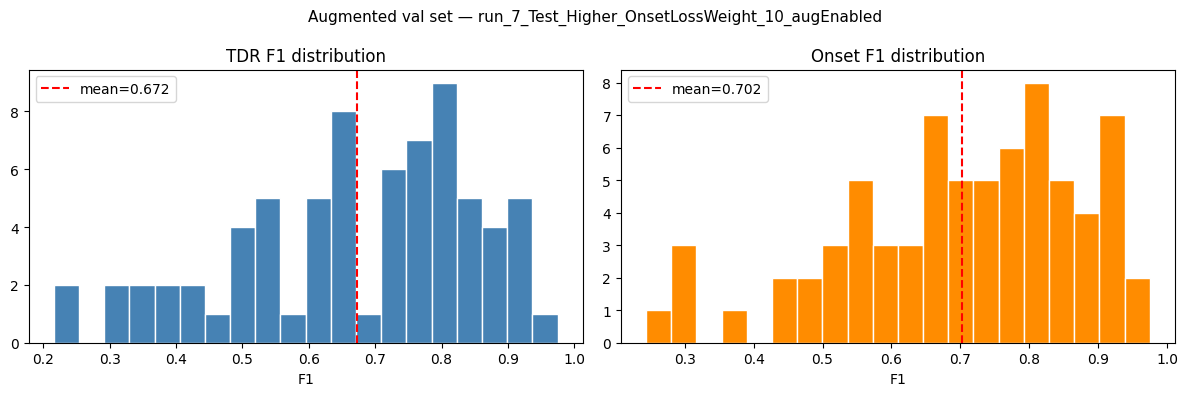

In [37]:
# ── Distribution plots — Augmented ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Augmented val set — {run_dir.name}', fontsize=11)

axes[0].hist(df_aug['tdr_f1'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df_aug['tdr_f1'].mean(), color='red', linestyle='--', label=f'mean={df_aug["tdr_f1"].mean():.3f}')
axes[0].set_title('TDR F1 distribution')
axes[0].set_xlabel('F1'); axes[0].legend()

axes[1].hist(df_aug['onset_f1'], bins=20, color='darkorange', edgecolor='white')
axes[1].axvline(df_aug['onset_f1'].mean(), color='red', linestyle='--', label=f'mean={df_aug["onset_f1"].mean():.3f}')
axes[1].set_title('Onset F1 distribution')
axes[1].set_xlabel('F1'); axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
# ── Best and worst tracks — Augmented ─────────────────────────────────────────
n = 5
print(f'Top {n} tracks (TDR F1):')
print(df_aug.nlargest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))
print(f'\nBottom {n} tracks (TDR F1):')
print(df_aug.nsmallest(n, 'tdr_f1')[['track','tdr_f1','onset_f1','n_gt_notes']].to_string(index=False))

Top 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
 05_Rock1-130-A_solo 0.974790  0.974790          60
    02_SS3-98-C_solo 0.933852  0.957198         127
   05_SS3-84-Bb_solo 0.922414  0.922414         111
 02_Jazz3-150-C_solo 0.916667  0.937063          73
01_Rock3-117-Bb_comp 0.915545  0.658824         398

Bottom 5 tracks (TDR F1):
               track   tdr_f1  onset_f1  n_gt_notes
05_Funk1-114-Ab_comp 0.215827  0.243902         181
  02_BN2-166-Ab_comp 0.226027  0.301471         194
  02_Funk3-98-A_comp 0.294416  0.302703         130
    05_SS3-98-C_comp 0.311688  0.501362         199
05_Jazz2-110-Bb_comp 0.351111  0.310433         252
